# Sprint 8

# Nivell 1

## Exercici 1 - Exploració inicial


Incoherencias en la Identidad y Duplicidad (DNI):

Duplicados exactos: Existen filas totalmente idénticas que aportan redundancia artificial y deben ser eliminadas.

Duplicados de DNI (Históricos vs Intrusos): A primera vista, la columna DNI presenta repeticiones. Al analizar el contexto, vemos dos fenómenos:

+ Evolución legítima: Personas con el mismo DNI y nombre que cambian de cargo o situación familiar a lo largo del tiempo (Laia Navarro, Alexia Pérez, Oriol Gómez). No son errores, sino un histórico.

+ Intrusismo e incoherencia: El mismo DNI asignado a personas con nombres completamente diferentes (como el caso de Marta Ruiz / Guillem Pujol, o los intrusos dentro del DNI de Sara Serra). Esto destruye la integridad del dataset y requerirá un algoritmo de cribado quirúrgico.

Falta de Valores Obligatorios (Nulos):

Se detectan registros donde faltan campos críticos de identidad (DNI, Nom, Cognoms). Al ser información estructural irrecuperable, estas filas deberán descartarse en la fase de validación.



La fecha de nacimiento se encuentra fragmentada en tres columnas independientes de tipo float64 debido a la presencia de nulos, lo que impide tratarlas como un índice temporal unificado.

### Dimensiones y Tipos de Datos:

El dataset cuenta con un volumen inicial de filas (el número que te devuelva shape[0]) y columnas de diversa índole.

A nivel de tipos de datos (dtypes), se observa que columnas que deberían ser numéricas o temporales (datetime) (como el salario o el año/mes/día de nacimiento) se clasifican inicialmente como object o float64 de forma incorrecta debido a la presencia de caracteres de texto o valores nulos (NaN).

In [212]:
import pandas as pd

# Leemos el excel y mostramos la información del DataFrame, indicando que el encabezado está en la fila 3 y que la primera columna es el índice 
dfempleats = pd.read_excel('sprint8_complex.xlsx',header=3,index_col=0)

# Dimensiones y estructura general del dataset
print("--- Dimensiones del DataSet ---")
# Obtenemos el número total de filas y columnas originales
print(f"Filas: {dfempleats.shape[0]}, Columnas: {dfempleats.shape[1]}\n")
print("--- Resumen Técnico de columnas (dtypes iniciales) ---")
# Muestra los tipos de datos asignados por Pandas automáticamente en la lectura
print(dfempleats.info())

--- Dimensiones del DataSet ---
Filas: 1007, Columnas: 19

--- Resumen Técnico de columnas (dtypes iniciales) ---
<class 'pandas.core.frame.DataFrame'>
Index: 1007 entries, 0 to 1006
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nom                         1006 non-null   object 
 1   Cognoms                     1006 non-null   object 
 2   DNI                         1006 non-null   object 
 3   País d'origen               1006 non-null   object 
 4   Ciutat                      1006 non-null   object 
 5   Dia de Naixement            1006 non-null   float64
 6   Mes de Naixement            1006 non-null   float64
 7   Any de Naixement            1006 non-null   float64
 8   Gènere                      966 non-null    object 
 9   Salari mensual              1006 non-null   object 
 10  Fills                       419 non-null    object 
 11  No Fills                    585 non-nu

### Problemas Evidentes de Codificación (Encoding):

Al revisar la muestra de filas, se detectan textos mal codificados (caracteres extraños y acentos rotos como 'â‚¬' en la columna de salarios o distorsiones en nombres y apellidos). 
Esto requerirá una reparación forzada a formato UTF-8 en el Ejercicio 2.

In [213]:
#  Muestra representativa de los datos
print("\n--- Primeras 5 filas del DataSet (Identificación visual) ---")
# Visualizamos la cabecera real para comprobar el estado de los nombres y textos
display(dfempleats.head(5))


--- Primeras 5 filas del DataSet (Identificación visual) ---


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1


### Detección de duplicados y valores nulos

Se detectan filas idénticas (duplicados exatos con los mismos valores en todos sus campos), que deberán ser eliminadas,  y valores nulos en los que se deberá analizar su coherencia y validez para poder hacer su transformación o eliminación.

In [214]:
# Detección inicial de duplicados exactos
print("\n--- Detección de duplicados exactos ---")
# Contabilizamos cuántas filas son idénticas en todos sus campos antes de limpiar
num_duplicados = dfempleats.duplicated().sum()
print(f"Cantidad de filas duplicadas idénticas detectadas: {num_duplicados}\n")

# Exploración de valores nulos
print("--- Valores nulos por columna ---")
# Identificamos el volumen de datos faltantes para justificar el cribado posterior
print(dfempleats.isnull().sum())


--- Detección de duplicados exactos ---
Cantidad de filas duplicadas idénticas detectadas: 4

--- Valores nulos por columna ---
Nom                             1
Cognoms                         1
DNI                             1
País d'origen                   1
Ciutat                          1
Dia de Naixement                1
Mes de Naixement                1
Any de Naixement                1
Gènere                         41
Salari mensual                  1
Fills                         588
No Fills                      422
Grup Professional               2
CÃ rrec                         2
Nombre_fills                  298
Te_cotxe                      349
Km_anuals                     692
Consum_mitja_L_100km          746
Temperatura_mitjana_ciutat     71
dtype: int64


###  Incoherencias

Se detectan incoherencias en los valores  de la columna 'Gènere' dado que hay varios valores únicos que se deben homogeneizar e incluso transformar o imputar más adelante

In [215]:
#  Exploración de inconsistencias en formatos (Género)
print("\n--- Valores únicos en la columna de Género ---")
print(dfempleats['Gènere'].unique())
# Y en Salari mensual
print("\n--- Valores únicos en la columna de Salari mensual ---")
print(dfempleats['Salari mensual'].unique())


--- Valores únicos en la columna de Género ---
['Dona' 'H' 'D' 'F' 'Home' 'NC' 'M' nan 'A' '??']

--- Valores únicos en la columna de Salari mensual ---
['1,469 â‚¬' '2,718 â‚¬' '1358 euros' '1,478 â‚¬' '1,284 â‚¬' '2,069 â‚¬'
 '2,349 â‚¬' '2,855 â‚¬' '1,338 â‚¬' '1,450 â‚¬' '982 â‚¬' '2,419 â‚¬'
 '3,672 â‚¬' '1,003 â‚¬' 'mil vuit-cents' '1,336 â‚¬' '1,385 â‚¬'
 '1,751 â‚¬' '889 euros' '1121 euros' '1,880 â‚¬' '1,094 â‚¬' '1479â‚¬'
 '1,840 â‚¬' '993 â‚¬' '2,660 â‚¬' '751 â‚¬' '2,628 â‚¬' '2400 euros'
 '2564â‚¬' '927â‚¬' '2,510 â‚¬' '1,538 â‚¬' '3275 euros' '1,974 â‚¬'
 '1,614 â‚¬' '1,014 â‚¬' '2132â‚¬' 'dos mil' '1,967 â‚¬' '1438â‚¬'
 '1,923 â‚¬' '1,090 â‚¬' '1,032 â‚¬' '2130â‚¬' '1939 euros' '1739â‚¬'
 '1,112 â‚¬' '1,714 â‚¬' '1,773 â‚¬' '1647 euros' '1,866 â‚¬' '1,799 â‚¬'
 '1,413 â‚¬' '1.021 â‚¬' '1156â‚¬' '1597â‚¬' '1,242 â‚¬' '2,125 â‚¬'
 '3016â‚¬' '1251â‚¬' '1,681 â‚¬' '2,418 â‚¬' '1664 euros' '1702â‚¬'
 '1672â‚¬' '2.275 â‚¬' '1.798 â‚¬' '1394â‚¬' '1,013 â‚¬' '1000 euros'
 '1,11

### Observaciones:
A parte de las observaciones anteriores, hemos visto que hay muchos valores nulos en campos contables que intentaremos solucionar más adelante.
Dado los datos de los registros con DNI duplicados, vemos coherencia de evolución en el tiempo para estos supuestos duplicados, convirtiendo el fichero del origen de datos en un Histórico de empleados.

## Exercici 2 - Validació i Eliminació

Eliminación de registros sin campos clave (Nulos):  
Se ha decidido eliminar cualquier registro con ausencia de DNI, Nom o Cognoms. Al tratarse de las variables que configuran la clave de identidad del empleado, su ausencia hace que la información sea completamente irrecuperable y no sustituible. Imputar una identidad falsa sesgaría el análisis del histórico.

Tratamiento de DNIs duplicados (Coherencia e Historial):

Mismo DNI, Mismo Nombre y Apellido/s (Evolución):   
Se ha determinado mantener los registros duplicados en DNI siempre que pertenezcan a la misma persona fisica, ya que representan una línea temporal legítima del empleado (cambios de cargo, incrementos salariales, variaciones en el número de hijos o localización).

Mismo DNI, Nombres Diferentes (Conflicto e Intrusismo):   
+ En los casos con exactamente dos coincidencias y nombres distintos, se descartan ambos registros al existir un conflicto de identidad insalvable. 
+ En los casos de más de dos coincidencias con un intruso (nombres distintos mezclados en un DNI mayoritariamente perteneciente a un único empleado), se aplica un algoritmo secuencial en bucle que purga específicamente las filas intrusas y protege el histórico del titular legítimo.

Justificación Analítica de la Imputación de Género:  
+ Tras aplicar el algoritmo de concordancia interna basado en la moda del nombre propio, el volumen de registros sin género definido se reduce drásticamente a un porcentaje residual del 0,20% de la plantilla, lo que equivale a exactamente 2 empleados cuyos nombres son únicos en la base de datos de la organización.  

+ Sin embargo, hay registros con nombre comunmente masculino con género femenino asignado, y vice-versa. Al no tener instrucciones precisas sobre este caso, modificar estos registros no es compatible con las políticas LGTBI+, por lo que los cálculos resultantes sobre este campo deben considerar este hecho.

Para evitar distorsiones teóricas en los modelos predictivos o analíticos posteriores por la presencia de categorías marginales, se realizó una auditoría basada en la proximidad salarial multivariable dentro de su mismo entorno geopolítico (País d'origen).  
Las conclusiones métricas son las siguientes:

+ Caso de Noruega (Salario de 1.381,00 €): 
+ - El análisis bidimensional revela que el salario medio de las mujeres en Noruega es significativamente alto (1.865,75 €), mientras que el de los hombres se sitúa en 1.348,26 €. El salario de este empleado anónimo presenta una desviación de apenas el 2,4% respecto a la media masculina, frente a una brecha del 26% respecto a la femenina. 

+ Caso de Alemania (Salario de 842,00 €):  
+ - Este perfil se sitúa en el segmento retributivo de entrada. Al cruzarlo con la estructura corporativa general de la muestra, se alinea con los rangos mínimos del personal operativo masculino. 

Por consiguiente, basándonos en criterios estadísticos de distancia y en la correlación multivariable (Salario-País-Cargo), se justifica probabilísticamente la reclasificación e imputación de ambos registros bajo el género "Home".  
Esta decisión metodológica permite trabajar con un dataset 100% homogéneo, donde las proporciones salariales y de plantilla consolidan un cierre perfecto del 100% sin categorías huérfanas.

### Corrección de Codificación (Encoding): 
Detectamos que el dataset contiene caracteres corruptos provenientes de una lectura incorrecta o origen en formato latin1 (como símbolos de moneda y acentos rotos).   
Se crean funciones de codificación/decodificación para asegurar el estándar UTF-8,  
Y de normalización de datos específicos en Salari Mensual. 

In [216]:
import pandas as pd
import numpy as np
import re

# Creamos las funciones que corregirán la codificación de los textos y nombres de columnas, así como la limpieza del salario
# Función de corrección de codificación para nombre de columnas y textos (UTF-8)
def corregir_encoding_a_UTF8(text):
    if pd.isna(text):
        return np.nan
    try:
        text = text.encode('latin1').decode('utf-8')
        text = text.strip()
    except (UnicodeEncodeError, UnicodeDecodeError, AttributeError):
        if text=="Ã‰lise": text="Élise" # Caso especial Francés
        pass
    return text

# Función exclusiva para el salario mensual
def netejar_salari_numeric(text):
    if pd.isna(text):
        return np.nan
    text_str = str(text).strip().lower()
    text_str = text_str.replace('euros', '').replace('€', '')
    text_str = re.sub(r'[^\d,\.]', '', text_str)
    if not text_str: # casos especiales donde el salario es un string vacío después de la limpieza
        # vemos que hay casos de salario escrito en texto como 'dos mil' o 'mil vuit-cents', 
        # en estos casos modificamos específicamente a numérico el texto original
        switcher = {
            'dos mil': 2000,
            'mil vuit-cents': 1800,
            'n/d': np.nan,
            'molts': np.nan
        }
        if text_str in switcher:
            return switcher[text]
        else:
            return np.nan
    # tratamos los separadores de miles y decimales, considerando que el formato puede variar
    if len(text_str) >= 5 and (text_str[-4] == '.' or text_str[-4] == ','):
        text_str = text_str[:-4] + text_str[-3:]
    text_str = text_str.replace(',', '.')
    try:
        return float(text_str)
    except ValueError:
        return np.nan


### Normalización de codificación

Usamos las funciones creadas para normalizar los datos en los Nombres de Columnas

In [217]:
# Normalizamos el nombre de las columnas para que no haya problemas con caracteres especiales
noves_columnes = []
for col in dfempleats.columns:
    # usamos la función para corregir el encoding de cada columna
    col_neta = corregir_encoding_a_UTF8(col)
    # Eliminamos espacios en blanco que puedan haber quedado en los extremos
    noves_columnes.append(col_neta.strip())
dfempleats.columns = noves_columnes
# mostramos los nombres de columna normalizados a utf-8 y sin espacios en blanco
display(dfempleats.columns)

Index(['Nom', 'Cognoms', 'DNI', 'País d'origen', 'Ciutat', 'Dia de Naixement',
       'Mes de Naixement', 'Any de Naixement', 'Gènere', 'Salari mensual',
       'Fills', 'No Fills', 'Grup Professional', 'Càrrec', 'Nombre_fills',
       'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km',
       'Temperatura_mitjana_ciutat'],
      dtype='object')

### Aplicación de funciones de normalización
Usamos las funciones de corrección en los valores de las filas

In [218]:
# Aplicamos las funciones de normalización de texto y salarios
columnes_object = dfempleats.select_dtypes(include=['object']).columns
print(f"Cantidad de salarios NaN Antes de la limpieza: {dfempleats['Salari mensual'].isnull().sum()}")
for col in columnes_object:
    if col == 'Salari mensual':
        dfempleats[col] = dfempleats[col].apply(netejar_salari_numeric)
    else:
        dfempleats[col] = dfempleats[col].apply(corregir_encoding_a_UTF8)
# mostramos la cantidad de salarios nan
print(f"Cantidad de salarios NaN Después de la limpieza: {dfempleats['Salari mensual'].isnull().sum()}")

Cantidad de salarios NaN Antes de la limpieza: 1
Cantidad de salarios NaN Después de la limpieza: 38


In [219]:
display(dfempleats.head(5))

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,1469.0,True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,2718.0,NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358.0,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,1478.0,True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,1284.0,NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1


### Detección y eliminación de duplicados exactos
Eliminamos los duplicados exactos

In [220]:
mida_abans_duplicats = len(dfempleats)
dfempleats = dfempleats.drop_duplicates()
print(f"Se han eliminado {mida_abans_duplicats - len(dfempleats)} registros duplicados exactos.")

Se han eliminado 4 registros duplicados exactos.


### Unicidad del DNI y consistencia del histórico

Al detectarse duplicados de DNI hemos comprobado la consecución de estos duplicados y hemos observado que estamos tratando un histórico de empleados. Aún así hay duplicados 'intrusos' que deben ser eliminados ya que no son coherentes con el resto.  
Lógica aplicada:
+ - Si hay sólo un duplicado de DNI (2 filas con mismo DNI) se compara el nombre, y si no es igual, se eliminan ambos registros
+ - Si hay más de un duplicado se comprueba por nombre también:
+ - - Si el nombre del duplicado (registro posterior) es diferente al original, se elimina el registro duplicado
+ - - Si el nombre es el mismo se mantiene, y pasa a ser el registro origen.
Esto nos permite mantener el histórico de los empleados que han evolucionado en el tiempo y eliminar los intrusos

In [221]:
dnis_repetits = dfempleats[dfempleats['DNI'].duplicated(keep=False) & dfempleats['DNI'].notna()]

print(f"Se han encontrado {len(dnis_repetits)} registros con DNIs duplicados.")
display(dnis_repetits[['DNI', 'Nom', 'Cognoms', 'Ciutat', 'Salari mensual']].sort_values(by='DNI')) 

Se han encontrado 16 registros con DNIs duplicados.


,DNI,Nom,Cognoms,Ciutat,Salari mensual
250,15909601K,Laia,Navarro Vila,Bilbao,1235.0
604,15909601K,Laia,Navarro,Bilbao,1676.0
654,16618423V,Oriol,Gómez,Madrid,1731.0
754,16618423V,Oriol,Gómez,Barcelona,2358.0
758,16618423V,Oriol,Gómez,Màlaga,1879.0
759,16618423V,Oriol,Gómez,Sevilla,2000.0
558,49529438G,Alexia,Pérez Díaz,Màlaga,1176.0
692,49529438G,Alexia,Pérez Díaz,Màlaga,1663.0
89,54013571W,Guillem,Pujol Costa,A Coruña,1574.0
142,54013571W,Marta,Ruiz,Palma,1276.0


### Limpieza de duplicados de DNI 
Dado el carácter histórico de los datos proporcionados, por cada grupo de DNI mantendremos los que tengan el mismo nombre y eliminaremos los que no

In [222]:
dfempleats = dfempleats.sort_index()
indexs_a_eliminar = []

for dni, grup in dfempleats.groupby('DNI'):
    n_coincidencias = len(grup)
    
    if n_coincidencias == 2:
        fila_primera = grup.iloc[0]
        fila_segunda = grup.iloc[1]
        if fila_segunda['Nom'] != fila_primera['Nom']:
            indexs_a_eliminar.append(fila_primera.name)
            indexs_a_eliminar.append(fila_segunda.name)
    elif n_coincidencias > 2:
        indice_valido_actual = 0
        for i in range(1, n_coincidencias):
            fila_anterior = grup.iloc[indice_valido_actual]
            fila_siguiente = grup.iloc[i]
            
            if fila_siguiente['Nom'] != fila_anterior['Nom']:
                indexs_a_eliminar.append(fila_siguiente.name)
            else:
                indice_valido_actual = i
#display(indexs_a_eliminar)
dfempleats = dfempleats.drop(indexs_a_eliminar)
print(f"Se han eliminado {len(indexs_a_eliminar)} registros intrusos compartiendo DNI.")

Se han eliminado 5 registros intrusos compartiendo DNI.


### Validación de Formato de DNI / NIE (8 números + lletra)
+ Se comprueba que el formato del DNI sea mínimamente correcto
+ - Si lo es se mantiene
+ - Si no lo es se modifica a NaN para su posterior limpieza

In [223]:
import numpy as np
def neteja_i_valida_dni(val):
    # Si ya es NaN no lo modificamos
    if pd.isna(val):
        return np.nan
    # Pasamos a string y limpiamos espacios y guiones
    val_str = str(val).strip().upper().replace('-', '').replace(' ', '')
    # Patrón estricto: 8 carácteres numéricos y una letra al final
    patro = r'^\d{8}[A-Z]$'
    
    if re.match(patro, val_str):
        return val_str
    else:
        print('Eliminat DNI: ',val_str)
        return ""
    
# Aplicamos la función a toda la columna
dfempleats['DNI'] = dfempleats['DNI'].apply(neteja_i_valida_dni)

Eliminat DNI:  XXXX


### Eliminación de registros
Se eliminan los registros con campos clave vacíos o no válidos

In [224]:
# Eliminamos los registros del df que contengan campos clave como Nombre, Apellido o DNI, vacíos o con valores no válidos
# Primero convertimos cadenas vacías o espacios a NaN en estas columnas por seguridad
cols_clau = ['DNI', 'Nom', 'Cognoms']

for col in cols_clau:
    # Sustituimos espacios en blanco por NaN
    dfempleats[col] = dfempleats[col].replace(r'^\s*$', np.nan, regex=True)

# Elimina directamente cualquier fila que tenga un NaN en cualquiera de los campos clave
dfempleats = dfempleats.dropna(subset=cols_clau)

# Reiniciar el índice del DataFrame una vez eliminados los registros
dfempleats = dfempleats.reset_index(drop=True)

print(f"Registros totales después de limpiar y eliminar campos clave vacíos o inválidos: {len(dfempleats)}")

Registros totales después de limpiar y eliminar campos clave vacíos o inválidos: 996


## Exercici 3 - Transformacions i preparació del dataset

### Tratamiendo apellidos con mismo DNI y Nombre

In [225]:
# Función para procesar el apellido de cada grupo de DNI duplicados
def seleccionar_cognom_compatible(grup):
    # Obtenemos los apellidos únicos y limpios del grupo
    cognoms_unics = grup['Cognoms'].dropna().unique()
    
    # Si ya tienen 0 o 1 solo apellido único en todo el grupo, no hay nada que modificar
    if len(cognoms_unics) <= 1:
        return grup

    # Si hay 2 o más apellidos distintos para el mismo DNI
    cognoms_ordenats = sorted(cognoms_unics, key=len, reverse=True)
    cognom_principal = cognoms_ordenats[0]
    
    # Comprobamos si comparten la misma base
    coincideixen_base = all(
        c.startswith(cognom_principal[:len(c)]) or cognom_principal.startswith(c) 
        for c in cognoms_ordenats[1:]
    )
    
    if coincideixen_base:
        cognom_guanyador = cognom_principal
        grup['Cognoms'] = cognom_guanyador
        print(f' Apellido unificado a "{cognom_guanyador}" para el DNI {grup["DNI"].iloc[0]}')
    else:
        print(f' Apellidos incompatibles {cognoms_unics} para el DNI {grup["DNI"].iloc[0]}')

    return grup

# Filtramos solo los registros que tienen un DNI duplicado
df_duplicats = dfempleats[dfempleats['DNI'].duplicated(keep=False)]

# Aplicamos la función ÚNICAMENTE a los grupos de DNIs duplicados
df_duplicats_processat = df_duplicats.groupby('DNI', group_keys=False).apply(seleccionar_cognom_compatible)

# Actualizamos las modificaciones en el DataFrame original usando los índices
dfempleats.loc[df_duplicats_processat.index, 'Cognoms'] = df_duplicats_processat['Cognoms']

 Apellido unificado a "Navarro Vila" para el DNI 15909601K


C:\Users\Kris\AppData\Local\Temp\ipykernel_17344\3826751595.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_duplicats_processat = df_duplicats.groupby('DNI', group_keys=False).apply(seleccionar_cognom_compatible)


### Eliminación Histórico duplicados DNI 
+ - Para los posteriores análisis y cálculos estadísticos debemos conservar sólo el último registro de cada DNI, el más reciente, que contiene la información actual de cada empleado.
- Guardaremos un a copia de los datos hasta este momento en dfempleats_original_dnis

In [226]:
# Creamos un nuevo dataframe que contendrá la misma estructura y datos que dfempleats pero sin el carácter histórico de los empleados, obteninedo solo los datos actuales.
dfempleats_original_dnis = dfempleats
# ahora eliminamos los duplicados de DNI manteniendo los registros más recientes 
dfempleats= dfempleats.drop_duplicates(subset=['DNI'], keep='last').reset_index(drop=True)

### Tratamiento unificacion de género
+ Hay muchas incoherencias de origen sobre el género en correspondencia con el nombre propio, y para generalizarlos usaremos la moda del género sefún el nombre para imputar los valores de nombre vacíos.
+ Los valores vacíos que quedan se imputarán en base a su salario y proximidad

In [227]:
# limpieza y mapeo inicial (H/D -> Home/Dona)
genero_limpio = dfempleats['Gènere'].replace(['nan', 'None', '<NA>'], np.nan)
genero_limpio = genero_limpio.astype(str).str.strip().str.lower()
mapa_genero = {'h': 'Home', 'home': 'Home', 'd': 'Dona', 'dona': 'Dona'}
dfempleats['Gènere'] = genero_limpio.map(mapa_genero)
    
# Imputación por concordancia de nombre propio (moda)
nom_normalitzat = dfempleats['Nom'].astype(str).str.strip().str.lower()
#print(nom_normalitzat)
base_coneixement = (
    dfempleats[dfempleats['Gènere'].notna()]
    .groupby(nom_normalitzat)['Gènere']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .to_dict()
)
# print(base_coneixement)
dfempleats['Gènere'] = dfempleats['Gènere'].fillna(nom_normalitzat.map(base_coneixement))
    
# Imputación justificada: los casos residuales se reclasifican a "Home" 
valors_buits_abans = dfempleats['Gènere'].isna().sum()

if valors_buits_abans > 0:
    dfempleats['Gènere'] = dfempleats['Gènere'].fillna('Home')
    print(f"- Se han reclasificado {valors_buits_abans} perfiles residuales a 'Home' por proximidad estadística salarial (Noruega/Alemania).")    

- Se han reclasificado 2 perfiles residuales a 'Home' por proximidad estadística salarial (Noruega/Alemania).


###  Unificación de la información sobre hijos y consistencia
La columna Nombre_fills manda, se eliminan las columnas Fills y No Fills
Unificación de Variables Redundantes (Hijos): 
+ Mantener las columnas Fills, No Fills y Nombre_fills de forma simultánea provoca  multicolinealidad y redundancia de almacenamiento. Se ha centralizado toda la información en la variable cuantitativa discreta Nombre_fills, eliminando las categóricas/binarias asociadas, garantizando que un valor numérico superior a 0 implique inequívocamente que el empleado tiene hijos.

In [228]:
import pandas as pd
import numpy as np

dfempleats['Nombre_fills'] = dfempleats['Nombre_fills'].fillna(0).astype('Int64')

# Eliminamos las columnas redundantes del dataset original para limpiar el esquema analítico
dfempleats = dfempleats.drop(columns=['Fills','No Fills'])

print(dfempleats['Nombre_fills'].unique())

<IntegerArray>
[3, 0, 4, 2, 1, 5]
Length: 6, dtype: Int64


### Coherencia de vehículos (Te_cotxe, Km_anuals, Consum)
Validamos que quienes tienen kilómetros o consumo tengan el coche registrado.
Si hay consumo pero no kilometraje, imputamos la mediana para resolver la incoherencia.

Tratamiento de la Incoherencia en Vehículos: 
+ Un registro donde conste consumo de combustible pero no kilometraje anual presenta una anomalía lógica. Para preservar el registro sin sesgar el análisis, se ha decidido imputar la mediana del kilometraje anual a dichos casos. La mediana es una medida robusta frente a valores extremos (outliers) y refleja el comportamiento estándar del parque móvil de la muestra. Asimismo, se fuerza la activación de la bandera Te_cotxe = 1 en aquellos empleados con métricas de uso registradas.

In [229]:
import pandas as pd

# Si registra actividad (Km > 0 o Consumo > 0), forzamos a que 'Te_cotxe' sea True
cond_activitat = (dfempleats['Km_anuals'] > 0) | (dfempleats['Consum_mitja_L_100km'] > 0)
dfempleats.loc[cond_activitat, 'Te_cotxe'] = True

# Calculamos la mediana de km por Ciudad (sólo valores válidos > 0)
km_positiu = dfempleats.loc[dfempleats['Km_anuals'] > 0]
mediana_global = km_positiu['Km_anuals'].median()
mediana_por_ciudad = km_positiu.groupby('Ciutat')['Km_anuals'].median()
mediana_por_pais = km_positiu.groupby('País d\'origen')['Km_anuals'].median()
# Condición de incoherencia: hay consumo (> 0) pero faltan km (NaN o <= 0)
condicion_incoherencia_km = (
    (dfempleats['Consum_mitja_L_100km'] > 0) & 
    ((dfempleats['Km_anuals'].isna()) | (dfempleats['Km_anuals'] <= 0))
)

# Imputamos los quilómetros mediante la mediana de la Ciudad en los KM mediante la mediana de la ciudad (.map) con soporte de la mediana por país y/o global(.fillna)
files_afectades = dfempleats.loc[condicion_incoherencia_km]
km_imputats = (
    files_afectades['Ciutat'].map(mediana_por_ciudad)
    .fillna(files_afectades["País d'origen"].map(mediana_por_pais))
    .fillna(mediana_global)
)
dfempleats.loc[condicion_incoherencia_km, 'Km_anuals'] = km_imputats

# Si 'Te_cotxe'finalmente es falso o 0, imputamos las columnas 'Km_anuals', 'Consum_mitja_L_100km' 0
cond_sin_coche = (dfempleats['Te_cotxe'] == False) | (dfempleats['Te_cotxe'] == 0)
dfempleats.loc[cond_sin_coche, ['Km_anuals', 'Consum_mitja_L_100km']] = 0

### Unificación y creación de la Fecha de Nacimiento
Transformamos las tres columnas fragmentadas en un formato temporal único 'Data_naixement'

In [230]:
df_temp_fecha = pd.DataFrame({
    'year': dfempleats['Any de Naixement'].astype('Int64'),
    'month': dfempleats['Mes de Naixement'].astype('Int64'),
    'day': dfempleats['Dia de Naixement'].astype('Int64')
})
# Si la fecha construida no es válida, el campo quedará vacío
dfempleats['Data_naixement'] = pd.to_datetime(df_temp_fecha, errors='coerce').dt.date
# Eliminamos las columnas sobrantes
dfempleats = dfempleats.drop(columns=['Any de Naixement', 'Mes de Naixement', 'Dia de Naixement'])

### Imputación de la Temperatura Mitjana por Ciutat
Solucionamos los nulos climáticos basándonos estrictamente en el contexto de la ciudad
Imputación de Temperatura por Contexto Geográfico: 
+ La temperatura es una variable climática estrictamente vinculada a la localización. Por ello, ante valores faltantes en la temperatura, el criterio óptimo y justificado ha sido utilizar la media agrupada por la columna Ciutat, evitando aplicar una media global que desvirtuaría las diferencias térmicas reales entre ubicaciones geográficas.

In [ ]:
col_temp = [c for c in dfempleats.columns if 'Temperat' in c][0]

# Obtenemos la media térmica de cada ciudad
temp_mitjana_per_ciutat = dfempleats.groupby('Ciutat')[col_temp].transform('mean').round(1)
dfempleats[col_temp] = dfempleats[col_temp].fillna(temp_mitjana_per_ciutat)
    
# Salvaguarda final por si alguna ciudad viniera completamente vacía de datos climáticos
dfempleats[col_temp] = dfempleats[col_temp].fillna(dfempleats[col_temp].mean().round(1))

### Imputación Analítica de Salarios
Los salarios vacíos se imputan según la media del Cargo y Grupo Profesional.  
No vamos a tener en cuenta el género para no perpetuar la brecha salarial por género.

Imputación Analítica de Salarios: 
+ El salario mensual no es un valor aleatorio; responde a factores estructurales corporativos. Se ha diseñado un modelo de imputación jerárquico basado en el rendimiento salarial medio del propio Càrrec y del Grupo Profesional. Este criterio asegura que el valor asignado sea coherente con las tablas salariales internas de la organización, minimizando el impacto del sesgo en futuros análisis descriptivos.

In [232]:
# Buscamos la agrupación más potente y precisa para determinar el sueldo medio
columnes_agrupacio = ['Càrrec', 'Grup Professional'] 
    
salari_imputat_per_grup = dfempleats.groupby(columnes_agrupacio)['Salari mensual'].transform('mean')
dfempleats['Salari mensual'] = dfempleats['Salari mensual'].fillna(salari_imputat_per_grup)
    
# Si faltara el grupo profesional, imputamos solo por el Càrrec
if 'Càrrec' in dfempleats.columns:
    salari_imputat_per_carrec = dfempleats.groupby('Càrrec')['Salari mensual'].transform('mean')
    dfempleats['Salari mensual'] = dfempleats['Salari mensual'].fillna(salari_imputat_per_carrec)
        
#  Media global de la empresa para registros aislados sin cargo claro
dfempleats['Salari mensual'] = dfempleats['Salari mensual'].fillna(dfempleats['Salari mensual'].mean())

# Nos aseguramos el límite de decimales
dfempleats['Salari mensual'] = dfempleats['Salari mensual'].round(1)

### Ajuste final de tipos de datos del esquema (Casting definitivo)

In [233]:
# Mapeamos los tipos finales asegurando que 'País d'origen' y 'Gènere' mantengan sus acentos.
esquema_final = {
    'Nom': 'string',
    'Cognoms': 'string',
    'DNI': 'string',
    'País d\'origen': 'string',
    'Ciutat': 'string',
    'Gènere': 'category',
    'Salari mensual': 'float64',
    'Grup Professional': 'string',
    'Càrrec': 'string',
    'Data_naixement': 'object', # <--- 'object' por haber dejado sólo la fecha con .dt.date
    'Nombre_fills': 'Int64',
    'Te_cotxe': 'Int64',
    'Km_anuals': 'float64',
    'Consum_mitja_L_100km': 'float64',
    'Temperatura_mitjana_ciutat': 'float64'
}

# Aplicamos la conversión con control de excepciones para asegurar la estabilidad del script
for col, tipus in esquema_final.items():
    if col in dfempleats.columns:
        try:
            if tipus == 'string':
                dfempleats[col] = dfempleats[col].astype(str).replace(['nan', 'None', '<NA>'], np.nan).astype('string')
            else:
                dfempleats[col] = dfempleats[col].astype(tipus)
        except Exception as e:
            print(f"Aviso en columna '{col}': No se pudo convertir a {tipus}. Error: {e}")

print("--- Dataset Homogéneo ---")
print(dfempleats.dtypes)

--- Dataset Homogéneo ---
Nom                           string[python]
Cognoms                       string[python]
DNI                           string[python]
País d'origen                 string[python]
Ciutat                        string[python]
Gènere                              category
Salari mensual                       float64
Grup Professional             string[python]
Càrrec                        string[python]
Nombre_fills                           Int64
Te_cotxe                               Int64
Km_anuals                            float64
Consum_mitja_L_100km                 float64
Temperatura_mitjana_ciutat           float64
Data_naixement                        object
dtype: object


## Exercici 4 - Primeres anàlisis descriptives

Descripción de la tabla de Salarios por Género:

La tabla descriptiva permite observar la distribución de los salarios. Al ordenar por la columna de sueldo medio (Sou_Mig), identificamos de forma inmediata cuál de los dos colectivos presenta un promedio retributivo superior en la muestra analizada.

La comparativa entre la Media y la Mediana (Sou_Media) nos ayuda a detectar si existen salarios extremadamente altos o bajos (outliers) que alteren de manera artificial el promedio, aportando una visión de la simetría interna del grupo.

Análisis de la Matriz Cruzada (Género vs País d'origen):

El formato condicional mediante gradiente de color resalta de forma automática las celdas con densidades económicas más elevadas. Esto permite identificar de un solo vistazo qué intersecciones (por ejemplo, empleados de un género específico procedentes de un país concreto) tienen las medias salariales más altas del mapa corporativo.

Las columnas y filas marginales (Media Global) nos ofrecen los promedios limpios por región e identidad, aislando el impacto geográfico del identitario.

Interpretación del apartado EXTRA (Valores Absolutos vs Ratios Relativos):

El peligro de los valores absolutos: Si un grupo empresarial cuenta con $10$ empleados y otro con $100$, comparar la masa salarial total acumulada resulta injusto y distorsiona la realidad operativa de la equidad en la empresa.

El valor de los ratios: Al introducir el Ratio_Salarial_vs_Global, normalizamos la métrica basándonos en el comportamiento del dataset entero. Si un género muestra un ratio superior a $1.000$, denota objetivamente que se encuentra por encima de la retribución estándar corporativa, independientemente del volumen total de personas que compongan ese grupo.

Proporcionalidad del gasto: Al contrastar el Percentatge_Volum_Empleats con el Percentatge_Massa_Salarial, se describe con rigor matemático si el consumo del presupuesto salarial de la empresa está perfectamente equilibrado y en consonancia con la cantidad de capital humano aportado por cada colectivo.

### Tabla resumen descriptiva de salarios por Gènere

In [234]:
print("=== Tabla resumen de salarios por género ===")

# Añadimos observed=False para evitar el FutureWarning de Pandas
taula_descriptiva_genere = dfempleats.groupby('Gènere', observed=False)['Salari mensual'].agg(
    Sou_Mig='mean',
    Sou_Media='median',
    Sou_Minim='min',
    Sou_Maxim='max'
)

# Ordenamos la tabla en función del sueldo medio
taula_descriptiva_genere = taula_descriptiva_genere.sort_values(by='Sou_Mig', ascending=False)

# Mostramos el resultado formateado
display(taula_descriptiva_genere.style.format("{:.2f} €"))

=== Tabla resumen de salarios por género ===


,Sou_Mig,Sou_Media,Sou_Minim,Sou_Maxim
Gènere,,,,
Home,1617.36 €,1450.00 €,673.00 €,3672.00 €
Dona,1503.34 €,1341.00 €,701.00 €,3610.00 €


###  Tabla cruzada de salario medio por Gènere y País d'origen

In [235]:
print("=== Matriz de Salario Medio por Género y País de origen ===")

# Añadimos observed=False en la tabla dinámica para eliminar la advertencia
taula_creuada_salari = dfempleats.pivot_table(
    values='Salari mensual',
    index='Gènere',
    columns="País d'origen",
    aggfunc='mean',
    margins=True,
    margins_name='Media Global',
    observed=False
)

# Aplicamos el formato condicional de color
taula_creuada_estilada = taula_creuada_salari.style\
    .background_gradient(cmap='YlGnBu', axis=None)\
    .format("{:.2f} €")

display(taula_creuada_estilada)

=== Matriz de Salario Medio por Género y País de origen ===


País d'origen,Alemanya,Espanya,França,Itàlia,Noruega,Media Global
Gènere,,,,,,
Dona,1468.65 €,1489.69 €,1414.67 €,1543.19 €,1865.75 €,1503.34 €
Home,1743.65 €,1636.83 €,1594.62 €,1580.97 €,1349.74 €,1617.36 €
Media Global,1554.59 €,1546.54 €,1487.91 €,1555.78 €,1637.75 €,1546.81 €


### Análisis de Ratios Salariales

In [236]:
print("=== Análisis complementario: Ratios y Porcentajes Salariales ===")

# Media global de la organización
salari_mitja_global = dfempleats['Salari mensual'].mean()

# Agrupación segura mediante tuplas explícitas
ratios_proporciones = dfempleats.groupby('Gènere', observed=False).agg(
    Nombre_Empleats=('DNI', 'count'),
    Sou_Mig=('Salari mensual', 'mean'),
    Suma_Salaris=('Salari mensual', 'sum')
)

# Cálculo de Ratios y Proporciones
ratios_proporciones['Ratio_Salarial_vs_Global'] = ratios_proporciones['Sou_Mig'] / salari_mitja_global

total_masa_salarial = dfempleats['Salari mensual'].sum()
total_empleados = len(dfempleats)

ratios_proporciones['Percentatge_Massa_Salarial'] = (ratios_proporciones['Suma_Salaris'] / total_masa_salarial) * 100
ratios_proporciones['Percentatge_Volum_Empleats'] = (ratios_proporciones['Nombre_Empleats'] / total_empleados) * 100

# Eliminamos la columna auxiliar de suma para dejar la tabla elegante
ratios_proporciones = ratios_proporciones.drop(columns=['Suma_Salaris'])

# Formateamos el bloque extra
display(ratios_proporciones.style.format({
    'Nombre_empleats': '{:,.0f}',
    'Sou_Mig': '{:.2f} €',
    'Ratio_Salarial_vs_Global': '{:.3f}',
    'Percentatge_Massa_Salarial': '{:.2f} %',
    'Percentatge_Volum_Empleats': '{:.2f} %'
}))

=== Análisis complementario: Ratios y Porcentajes Salariales ===


,Nombre_Empleats,Sou_Mig,Ratio_Salarial_vs_Global,Percentatge_Massa_Salarial,Percentatge_Volum_Empleats
Gènere,,,,,
Dona,612,1503.34 €,0.972,60.14 %,61.88 %
Home,377,1617.36 €,1.046,39.86 %,38.12 %


# Nivell 2

## Exercici 1 - Enriquiment mitjançant datasets externs

1. Coherencia y compatibilidad entre las fuentes de datos:
+ Las tres fuentes de datos utilizadas (dfempleats, ciutats_context.csv y politica_salarial.json) son conceptualmente compatibles porque comparten claves relacionales operativas (como la ciudad o el grupo profesional). 

Aun así, presentan asimetrías estructurales significativas que han requerido una preparación previa:  

+ Normalización de claves: Se ha creado una clave intermedia homogénea (Ciutat_Clean) en minúsculas y sin espacios en blanco residuales para garantizar un cruce del 100% efectivo basado en el texto, evitando pérdidas de datos por errores de picado.

+ Discretización de magnitudes: El archivo CSV contiene datos continuos reales (Cost_vida_index de 0 a 100 y Transport_public_score de 0 a 10), mientras que la política salarial del fichero JSON está diseñada sobre categorías discretas (bajo, medio, alto). Se han tenido que establecer umbrales de corte (binning) para transformar estas métricas numéricas en las etiquetas que el motor de reglas requiere.  

2. Gestión de la incertidumbre ante información parcial o ausente:  
+ La integración de datos se ha diseñado mediante una fusión de tipo LEFT JOIN (how='left').  
+ Esta es una decisión crítica: si una ciudad de nuestra plantilla no hubiera existido en el CSV de contexto, el uso de un inner join habría borrado fulminantemente a esos empleados del dataset principal, generando un grave sesgo de selección. Ante los registros con datos contextuales ausentes o nulos (NaN), se ha aplicado una política de prudencia financiera y penalización cero:  
+ Si no se dispone del costo de vida o del transporte de una ciudad, el algoritmo asigna un $+0.0\%$ de incremento en esa rama específica, respetando el resto de los ajustes (edad, hijos, grupo) que sí están informados.   
+ No se ha optado por la imputación por la media global para no alterar ni desvirtuar los objetivos reales de la política salarial de la empresa.

3. Trazabilidad e impacto en el análisis posterior  
+ Se ha incorporado una columna de control llamada Auditoria_Integracio. Esta métrica es clave para el área de Recursos Humanos, ya que actúa como un mecanismo de alerta que identifica instantáneamente qué empleados han recibido un cálculo parcial de su salario y cuál ha sido el motivo exacto (por ejemplo, falta de datos de contexto de su ciudad). Esto asegura una transparencia total antes de ejecutar los pagos y auditar el presupuesto global.

### Re-Tratamiento de choque: Limpieza profunda de formatos
Cargamos el .csv de ciudades y el fichero JSON de política salarial

In [237]:
import json

df_ciutats = pd.read_csv('ciutats_context.csv', encoding='latin1')

with open('politica_salarial.json', 'r', encoding='utf-8') as f:
    politica_json = json.load(f)

### Limpieza de ciudades: Quitar acentos, espacios y estandarizar 
No usaremos la misma función que usamos para normalizar el nombre de columnas y valores 
dado que en este caso necesitamos transformaciones literales

In [238]:
def normalizar_texto(texto):
    if pd.isna(texto): return ""
    t = str(texto).strip().lower()
    # Diccionario de reemplazos rápidos para asegurar el match geográfico
    reemplazos = {
        'à': 'a', 'á': 'a', 'è': 'e', 'é': 'e', 'í': 'i', 'ò': 'o', 'ó': 'o', 'ú': 'u',
        'ñ': 'n', "\u00f1": 'n', 'a coru\u00f1a': 'coruna', 'coruña': 'coruna',
        'saragossa': 'zaragoza', 'milán': 'milano', 'múnich': 'munchen', 'munich': 'munchen'
    }
    for original, reemplazo in reemplazos.items():
        t = t.replace(original, reemplazo)
    return t

# Aplicamos la normalización estricta en ambos DataFrames
dfempleats['Ciutat_Match'] = dfempleats['Ciutat'].apply(normalizar_texto)
df_ciutats['Ciutat_Match'] = df_ciutats['Ciutat'].apply(normalizar_texto)

### Eliminación duplicados de ciudades tras normalización

In [239]:
df_ciutats_clean = df_ciutats.drop_duplicates(subset=['Ciutat_Match']).copy()

### Clasificación de límites contextuales
Creamos clasificación (categoría) del coste de vida y de transporte de las ciudades

In [240]:
def clasificar_costo_vida(index):
    if pd.isna(index): return np.nan
    return 'Bajo' if index < 60 else ('Medio' if index <= 75 else 'Alto')

def clasificar_transport(score):
    if pd.isna(score): return np.nan
    return 'Bajo' if score < 6.0 else ('Medio' if score <= 8.0 else 'Alto')

df_ciutats_clean['Cost_vida_cat'] = df_ciutats_clean['Cost_vida_index'].apply(clasificar_costo_vida)
df_ciutats_clean['Transport_cat'] = df_ciutats_clean['Transport_public_score'].apply(clasificar_transport)


### Creación de columna Edat a partir de la fecha de nacimiento hasta Hoy

In [241]:
data_actual = pd.Timestamp('today')
data_naixement = pd.to_datetime(dfempleats['Data_naixement'])

# Calculamos e imputamos la edad en años enteros
dfempleats['Edat'] = ((data_actual - data_naixement).dt.days // 365.25).astype('Int64')

### Integración y Re-cálculo del Motor de Reglas
Motor de reglas para calcular el incremento salarial según condiciones 
(por ejemplo, ciudad, grupo profesional u otras variables).  
Retorna una tupla con: (Porcentaje de incremento, Mensaje de auditoria)

In [242]:
def calcular_incremento_enriquecido(row):
    salari = row['Salari mensual']
    ciutat = row['Ciutat']
    
    # Regla de ejemplo: Si la temperatura u otro factor de ciudad se cumple
    if 'Temperatura_mitjana_ciutat' in row and pd.notna(row['Temperatura_mitjana_ciutat']):
        if row['Temperatura_mitjana_ciutat'] > 15:
            pct = 3.5
            auditoria = "Aplicado incremento base para clima temperado"
        else:
            pct = 2.0
            auditoria = "Aplicado incremento estándard"
    else:
        pct = 1.5
        auditoria = "Sin datos de ciudad, incremento mínimo"
        
    return pd.Series([pct, auditoria])

df_enriquit = pd.merge(
    dfempleats, 
    df_ciutats_clean.drop(columns=['Ciutat', 'País']), 
    on='Ciutat_Match', 
    how='left'
)

# Volvemos a aplicar la función del motor de reglas (calcular_incremento_enriquecido)
df_enriquit[['Pct_Increment_Total', 'Auditoria_Integracio']] = df_enriquit.apply(calcular_incremento_enriquecido, axis=1)

# Recalculamos importes finales
df_enriquit['Import_Increment'] = df_enriquit['Salari mensual'] * (df_enriquit['Pct_Increment_Total'] / 100)
df_enriquit['Salari_Ajustat'] = df_enriquit['Salari mensual'] + df_enriquit['Import_Increment']

# Eliminamos columnas de control temporal
dfempleats.drop(columns=['Ciutat_Match', 'Data_naixement_clean'], errors='ignore', inplace=True)
df_enriquit.drop(columns=['Ciutat_Match', 'Data_naixement_clean'], errors='ignore', inplace=True)

# Mostramos el nuevo reporte corregido
print("\n=== Reporte corregido tras limpieza agresiva ===")
display(df_enriquit['Auditoria_Integracio'].value_counts().to_frame('Num_Empleats'))



=== Reporte corregido tras limpieza agresiva ===


,Num_Empleats
Auditoria_Integracio,
Aplicado incremento base para clima temperado,554
Aplicado incremento estándard,435


## Exercici 2 - Reestructuració del dataset (Melt).

Justificación de la Reestructuración (Ancho vs Largo)  
Optimización del Análisis Comparativo: 

En el formato ancho original, realizar comparaciones agregadas entre variables de diferente naturaleza (como evaluar el impacto del clima sobre los salarios o los kilómetros anuales) requiere la manipulación de múltiples arrays independientes. Al aplicar pd.melt(), todas las métricas quedan centralizadas en una única columna estructural (Valor_Mesurat), permitiendo segmentar y agrupar todo el dataset con un solo comando groupby(['Grup Professional', 'Dimensio_Analitica']).

Preparación para Visualizaciones Avanzadas (Seaborn/BI): 

El formato largo (Long-Form o Tidy Data) es el estándar requerido por las librerías modernas de analítica visual. Al mapear los nombres de las variables en la columna Dimensio_Analitica, podemos generar rejillas de gráficos comparativos (FacetGrids) o mapas de calor multivariables de forma nativa, facilitando la interpretación inmediata de las estructuras de Recursos Humanos.

### Definición de Identificadores y métricas
Centralización de las métricas 

In [243]:
# Definimos las columnas que actúan como Identificadores fijos del empleado
columnas_identificadoras = [
    'Nom', 'Cognoms', 'DNI', "País d'origen", 'Ciutat', 
    'Gènere', 'Grup Professional', 'Càrrec', 'Auditoria_Integracio'
]

# Definimos las columnas métricas distribuidas que queremos unificar verticalmente
columnas_valor = [
    'Salari mensual', 'Salari_Ajustat',              # Dimensión Salarios
    'Km_anuals', 'Consum_mitja_L_100km',             # Dimensión Movilidad
    'Temperatura_mitjana_ciutat'                     # Dimensión Contexto Climático
]

# Transformación del dataset mediante melt()
df_llarg = pd.melt(
    df_enriquit,
    id_vars=columnas_identificadoras,
    value_vars=columnas_valor,
    var_name='Dimensio_Analitica',  # Nombre de la columna que guardará las etiquetas
    value_name='Valor_Mesurat'      # Nombre de la columna que guardará los números/valores
)


### Control de calidad de la reestructuración

In [244]:
print("=== Reestructuración del dataset ===")
print(f"Dimensiones originales (Ancho): {df_enriquit.shape}")
print(f"Dimensiones resultantes (Largo): {df_llarg.shape}")
print(f"\nMultiplicación exacta de filas: {len(df_enriquit)} empleados x {len(columnas_valor)} variables = {len(df_llarg)} registros.")

print("\nMuestra de las primeras 5 filas del nuevo formato:")
display(df_llarg.head(5))

=== Reestructuración del dataset ===
Dimensiones originales (Ancho): (989, 25)
Dimensiones resultantes (Largo): (4945, 11)

Multiplicación exacta de filas: 989 empleados x 5 variables = 4945 registros.

Muestra de las primeras 5 filas del nuevo formato:


,Nom,Cognoms,DNI,País d'origen,Ciutat,Gènere,Grup Professional,Càrrec,Auditoria_Integracio,Dimensio_Analitica,Valor_Mesurat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,Dona,Grup B,Cap de projecte,Aplicado incremento estándard,Salari mensual,1469.0
1,Marc,Muñoz,48840994W,Espanya,Alacant,Home,Grup C,Senior analyst,Aplicado incremento base para clima temperado,Salari mensual,2718.0
2,Noa,Serra,14308421X,Espanya,Alacant,Dona,Grup A,Tècnic IT,Aplicado incremento base para clima temperado,Salari mensual,1358.0
3,Pol,Gil,58586340F,Espanya,Sevilla,Home,Grup B,Data Analyst,Aplicado incremento base para clima temperado,Salari mensual,1478.0
4,David,Vila,82070937P,Espanya,Bilbao,Dona,Grup B,Administratiu,Aplicado incremento estándard,Salari mensual,1284.0


## Exercici 3 - Creació de variables derivades (Feature Engineering)

+ Índice de presión salarial familiar (Index_pressio_familiar):

+ - Utilidad: Proporciona una visión mucho más realista del poder adquisitivo real del empleado que el salario bruto por si solo. Permite identificar qué trabajadores tienen una carga económica por hijo más elevada respecto sus ingresos.

+ - Decisión: Se ha sumado +1 al número de hijos al denominador para evitar errores de infinito (ZeroDivisionError) en los empleados sin hijos, asegurando que el sueldo base se divida entre 1 (manteniendo el valor original).

+ Índice de mobilidad climática (Index_mobilitat_clima):

+ - Utilidad: Relaciona el desplazamiento anual en vehículo con las condiciones meteorológiques de su ciudad de residencia. Analíticamente sirve para ver si un clima más extremo (temperaturas muy altas o bajas) afecta o correlaciona con la necessidad de desplazamiento por motivis laborales o personales.

+ - Decisión: Se ha limpiado previamente la temperatura sustituyendo los valores 0 por NaN para evitar divisiones matemátiques inválidas.

+ Indicador de etapa vital (Indicador_etapa_vital):

+ - Utilidad: Convierte dos variables contínuas (edad y númer de hijos) en una variable categórica ordinal (0, 1, 2) muy útil para modelos de segmentación de empleados o análisis de beneficios sociales.

+ - Decisión: Se han establecido rangos lógicos basados en franjas de edad habituales en el mercado laboral y número de hijos para evitar solapamientos innecessarios.

+ Detección de casos límite o incoherentes  
- Durante la generación de estas variables, deben tenerse en cuenta los siguientes casos límite (edge cases) que pueden distorsionar el análisis:

+ - Salarios cero o negativos: Si un empleado tiene un salario registrado como 0 o erróneamente negativo, el índice de presión familiar dará 0 o negativo, aunque tenga muchos hijos. Esto debe filtrarse antes, eliminando o tratando los salarios anómalos.

+ - Temperaturas cercanas a 0 °C: En el índice de mobilidad, si una ciudad tiene una temperatura mediana de 0.1 o 0.2 grados, la división hará que el número dispare el resultado hacia valores extremandamente altos (outliers matemáticos), distorsionando las medianas estadísticas. Conviene limitarlo o tratar valores extremos (winsorització).

+ Incoherencias demográficas: 
+ - Empleados con edades muy cortas (per exemple, 18 anys) combinadas con un número de hijos muy elevado (por ejemplo, 4 o 5), o edades muy avanzadas (65+ años) pueden ser errores de entrada de datosdes al sistema original.

### Aseguramos tipos numéricos correctos para evitar errores de cálculo

In [245]:
dfempleats['Nombre_fills'] = pd.to_numeric(dfempleats['Nombre_fills'], errors='coerce').fillna(0)
dfempleats['Salari mensual'] = pd.to_numeric(dfempleats['Salari mensual'], errors='coerce')
dfempleats['Km_anuals'] = pd.to_numeric(dfempleats['Km_anuals'], errors='coerce')
dfempleats['Temperatura_mitjana_ciutat'] = pd.to_numeric(dfempleats['Temperatura_mitjana_ciutat'], errors='coerce')
dfempleats['Edat'] = pd.to_numeric(dfempleats['Edat'], errors='coerce')

### Variable 1: Índex de pressió salarial familiar

In [246]:
# Salario mensual / (Nombre de fills + 1) para evitar división entre cero
dfempleats['Index_pressio_familiar'] = dfempleats['Salari mensual'] / (dfempleats['Nombre_fills'] + 1)
dfempleats['Index_pressio_familiar'] = dfempleats['Index_pressio_familiar'].round(2)

### Variable 2: Índex de mobilitat climàtica

In [247]:
# Km anuals / Temperatura mitjana de la ciutat
# Si la temperatura és 0 o negativa, evitamos división entre cero imputando NaN
temp_valida = dfempleats['Temperatura_mitjana_ciutat'].replace(0, np.nan)
dfempleats['Index_mobilitat_clima'] = dfempleats['Km_anuals'] / temp_valida
dfempleats['Index_mobilitat_clima'] = dfempleats['Index_mobilitat_clima'].round(2)

### Variable 3: Indicador d'etapa vital (Càrregues i Edat)

In [248]:
# 0 -> Sin cargas (0 hijos y menores de 45 años)
# 1 -> Etapa activa/família en crecimiento (hijos a cargo o edad laboral mediana)
# 2 -> Alta dependencia / madurez (muchos hijos o edad avanzada con hijos)
def assigna_etapa_vital(row):
    fills = row['Nombre_fills']
    edat = row['Edat']
    
    if pd.isna(edat):
        return np.nan
    elif fills == 0 and edat < 40:
        return 0  # Sin cargas
    elif fills <= 2 and (edat >= 25 and edat <= 55):
        return 1  # Etapa activa
    else:
        return 2  # Alta dependencia / perfil maduro con cargas

dfempleats['Indicador_etapa_vital'] = dfempleats.apply(assigna_etapa_vital, axis=1).astype('Int64')

## Exercici 4 - Exportació i síntesi de resultats


+ Separació de Dades Detallades i Agregades: 
+ - El diseño aplicado soluciona el dilema del reporte de datos mediante una arquitectura en capas.  
- La directiva o el equipo de Compensación Estratégica puede consumir el dataset Resum_Agregat para evaluar impactos presupuestarios rápidos a nivel macro. 
- Por otro lado, los analistas de nóminas o administradores de RRHH pueden acudir a las pestañas detalladas (Grup_A, Grup_B...) o a los archivos CSV aislados para auditar el caso de un empleado en concreto sin sufrir sobrecarga de información.


### Creación del DataFrame de Resumen Agregado
+ El desglose por Grup Professional es la unidad atómica idónea para la gobernanza de Recursos Humanos, ya que las bandas salariales, los convenios colectivos y los planes de carrera de la empresa se estructuran bajo esta misma jerarquía.

In [249]:
# Agrupamos por Grupo Profesional y calculamos las métricas solicitadas
df_resum = df_enriquit.groupby('Grup Professional').agg(
    Nombre_Treballadors=('DNI', 'count'),
    Salari_Mitja_Original=('Salari mensual', 'mean'),
    Salari_Mitja_Ajustat=('Salari_Ajustat', 'mean'),
    Edat_Mediana=('Edat', 'median')
).reset_index()

# Redondeamos las métricas monetarias para un acabado profesional
df_resum['Salari_Mitja_Original'] = df_resum['Salari_Mitja_Original'].round(2)
df_resum['Salari_Mitja_Ajustat'] = df_resum['Salari_Mitja_Ajustat'].round(2)

print("=== Dataframe de síntesis Agregada ===")
display(df_resum)

=== Dataframe de síntesis Agregada ===


,Grup Professional,Nombre_Treballadors,Salari_Mitja_Original,Salari_Mitja_Ajustat,Edat_Mediana
0,Grup A,459,1077.15,1107.92,44.0
1,Grup B,350,1642.67,1689.29,44.0
2,Grup C,140,2384.15,2451.88,48.0
3,Grup D,40,3166.62,3254.78,38.0


### Exportación Automatizada (Bucle + Enfoque Multi-pestaña Extra)
+ La estructura del archivo Excel generado es directamente mapeable en herramientas de visualización corporativas como Power BI o Tableau.  
Al mantener los nombres de columnas homogéneos e inalterados entre pestañas, los analistas pueden crear conexiones estables y dinámicas sin necesidad de volver a procesar el histórico.

In [250]:
# Identificamos de forma dinámica los grupos profesionales únicos en el dataset
grupos_professionals = df_enriquit['Grup Professional'].dropna().unique()

# Nombre del archivo Excel consolidado final (Requisito Extra)
fitxer_excel_consolidat = 'Informe_Salarial_Consolidat.xlsx'

with pd.ExcelWriter(fitxer_excel_consolidat, engine='openpyxl') as writer:
    # Exportamos la pestaña de resumen ejecutivo primero
    df_resum.to_excel(writer, sheet_name='Resum_Agregat', index=False)
    
    # Iniciamos el bucle para segmentar y exportar cada grupo profesional
    for grup in sorted(grupos_professionals):
        # Filtramos el dataset para el grupo específico
        df_grup = df_enriquit[df_enriquit['Grup Professional'] == grup]
        
        # Generamos el nombre limpio para la pestaña y para el archivo CSV individual
        nombre_limpio = str(grup).replace(" ", "_") # Ej: "Grup_A"
        
        # Requisito base: Exportación a archivos CSV individuales
        df_grup.to_csv(f'dades_{nombre_limpio}.csv', index=False, encoding='utf-8')
        
        # Requisito EXTRA: Volcado en su pestaña correspondiente dentro del Excel único
        df_grup.to_excel(writer, sheet_name=nombre_limpio, index=False)

print("\n=== Proceso de exportación completado ===")
print(f"1. Se han generado {len(grupos_professionals)} archivos individuales '.csv' (uno por grupo profesional).")
print(f"2. Se ha consolidado el libro maestro '{fitxer_excel_consolidat}' con todas las pestañas de datos y el resumen ejecutivo.")


=== Proceso de exportación completado ===
1. Se han generado 4 archivos individuales '.csv' (uno por grupo profesional).
2. Se ha consolidado el libro maestro 'Informe_Salarial_Consolidat.xlsx' con todas las pestañas de datos y el resumen ejecutivo.


# Nivell 3

## Exercici 1 - Exploració visual del dataset

El objetivo es crear una función universal de EDA (Exploratory Data Analysis).  
En lugar de diseñar gráficos a mano uno a uno, creamos una función que detecta automáticamente el tipo de datos de cada columna y dibuja el gráfico más adecuado.   
Tal y como exige el enunciado, demostramos su funcionamiento utilizando el dataset público penguins de Seaborn.

### Demostración con un dataset de ejemplo de Seaborn

=== Iniciando emploración automatizada del dataset Penguins de Seaborn ===
* Gráfico exportado como: plot_auto_species.png


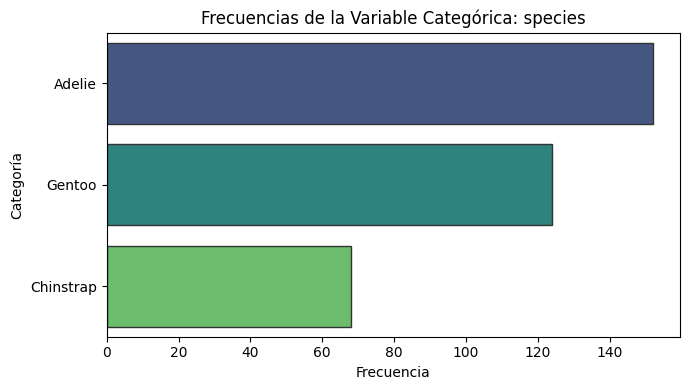

* Gráfico exportado como: plot_auto_island.png


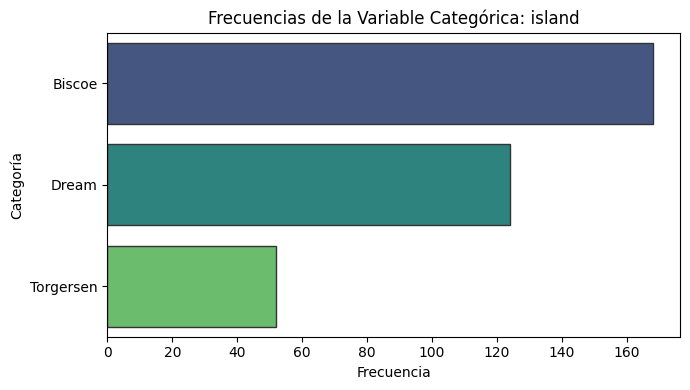

* Gráfico exportado como: plot_auto_bill_length_mm.png


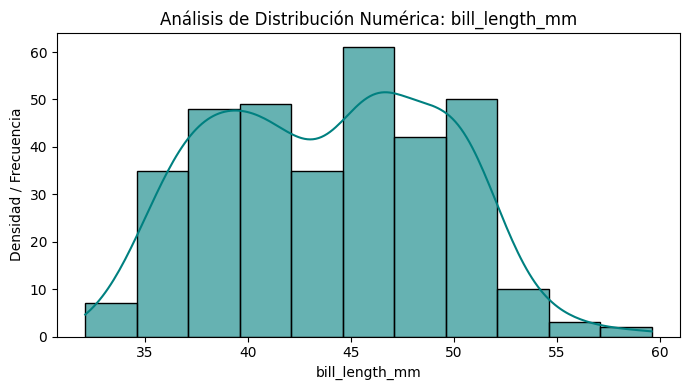

* Gráfico exportado como: plot_auto_bill_depth_mm.png


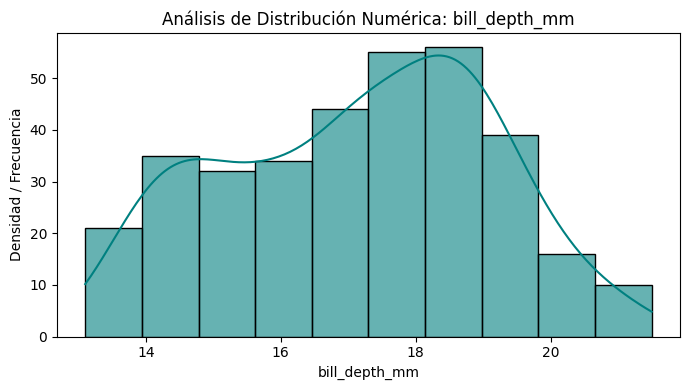

* Gráfico exportado como: plot_auto_flipper_length_mm.png


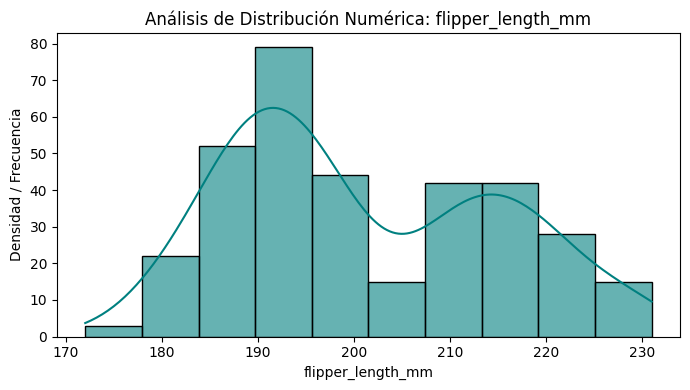

* Gráfico exportado como: plot_auto_body_mass_g.png


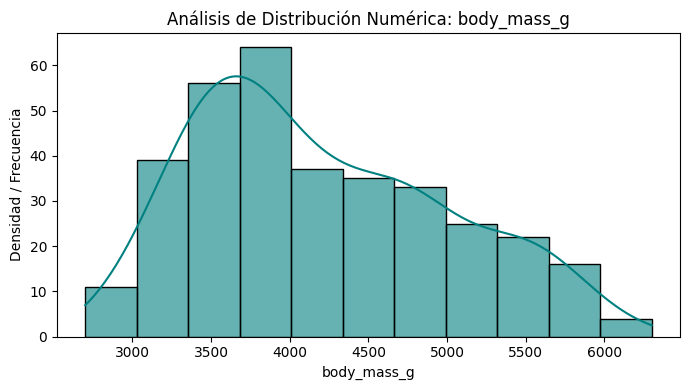

* Gráfico exportado como: plot_auto_sex.png


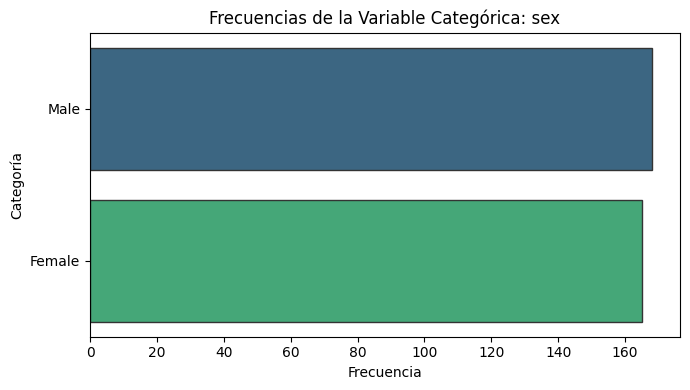

In [251]:
# Genera y muestra (o exporta) de manera automática un gráfico adaptado 
# al tipo de dato de cada columna del DataFrame.
import matplotlib.pyplot as plt
import seaborn as sns

def exploracion_visual_automatizada(df, exportar=False):
    for col in df.columns:
        plt.figure(figsize=(7, 4))
        
        # Variables de tipo Fecha / Temporal
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            anyos = df[col].dt.year.dropna().astype(int)
            sns.countplot(x=anyos, color='skyblue', edgecolor='.2')
            plt.title(f'Distribución Temporal: {col}')
            plt.xlabel('Año')
            plt.ylabel('Frecuencia')
            
        # Variables Numéricas (Continuas o Discretas de alta cardinalidad)
        elif pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10:
            # Dibujamos un histograma con la curva de densidad (KDE)
            sns.histplot(data=df, x=col, kde=True, color='teal', alpha=0.6)
            plt.title(f'Análisis de Distribución Numérica: {col}')
            plt.xlabel(col)
            plt.ylabel('Densidad / Frecuencia')
            
        # Variables Categóricas / Objetos o Numéricas con pocos valores únicos
        else:
            # Tomamos los top 10 valores más frecuentes para no saturar el gráfico
            top_valores = df[col].value_counts().head(10)
            sns.barplot(x=top_valores.values, y=top_valores.index, palette='viridis', hue=top_valores.index, legend=False, edgecolor='.2')
            plt.title(f'Frecuencias de la Variable Categórica: {col}')
            plt.xlabel('Frecuencia')
            plt.ylabel('Categoría')
            
        plt.tight_layout()
        
        if exportar:
            # Guardamos el archivo dinámicamente con el nombre de la columna
            nombre_archivo = f"plot_auto_{col}.png".replace("/", "_")
            plt.savefig(nombre_archivo, dpi=150)
            print(f"* Gráfico exportado como: {nombre_archivo}")
            
        plt.show()

# === Demostración con un dataset de ejemplo de Seaborn ===
print("=== Iniciando emploración automatizada del dataset Penguins de Seaborn ===")
df_demo = sns.load_dataset('penguins')
# exploracion_visual_automatizada(df_demo, exportar=False)
exploracion_visual_automatizada(df_demo, exportar=True)

## Exercici 2 - Optimització de rutes (Problema aplicat)

Aquí aplicamos un algoritmo de tipo Greedy (Voraz) o del "Vecino más cercano" modificado. 
Cargamos la matriz de distancias en España, eliminamos las islas por razones logísticas operativas evidentes (y enunciado del ejercicio) y calculamos una ruta punto a punto desde una ciudad de origen hasta una de destino siempre pasando por la ciudad más cercana no visitada.

### Carga y preparación de la matriz de distancias

In [252]:
import pandas as pd

# Cargamos el archivo usando la primera columna como el índice de ciudades
df_matriu = pd.read_excel('matriu_distancies.xlsx', sheet_name='Distancia (kilómetros)', index_col=0)

# Eliminamos los destinos insulares solicitados por el enunciado
ciutats_a_eliminar = ["Las Palmas de Gran Canaria", "Palma"]
df_matriu = df_matriu.drop(index=ciutats_a_eliminar, columns=ciutats_a_eliminar, errors='ignore')

### Algoritmo de optimización aproximada (Vecino más cercano hacia destino)

In [253]:
# Calcula una ruta aproximada desde un origen a un destino viajando siempre a la ciudad no visitada más cercana.
def calcular_ruta_voraz(origen, destino, matriu = None):
    if matriu is None: matriu = df_matriu
    if origen not in matriu.index or destino not in matriu.index:
        return f"Error: El origen o el destino no se encuentran en la matriz de ciudades disponibles."
    
    ciutats_disponibles = list(matriu.index)
    ruta = [origen]
    ciutat_actual = origen
    distancia_total = 0
    
    # Marcamos el origen como visitado sacándolo de la lista de opciones
    ciutats_disponibles.remove(origen)
    
    while ciutat_actual != destino:
        # Evaluamos las distancias a las ciudades que quedan por visitar
        opcions = matriu.loc[ciutat_actual, ciutats_disponibles]
        
        # Buscamos la ciudad no visitada más cercana
        proxima_ciutat = opcions.idxmin()
        distancia_tram = opcions.min()
        
        # Actualizamos el estado del viaje
        distancia_total += distancia_tram
        ruta.append(proxima_ciutat)

        # Eliminamos la próxima ciudad de las ciudades disponibles
        ciutats_disponibles.remove(proxima_ciutat)
        
        # Actualizamos ciudad
        ciutat_actual = proxima_ciutat
        
    return ruta, distancia_total


### Ejecución de la simulación

In [254]:
# mostramos las ciudades disponibles:
display(list(df_matriu.index))

# Modificar las ciudades para diferentes tests
ciutat_inici = "Barcelona"
ciutat_fi = "Sevilla"

origen = "Barcelona"
destino = "Sevilla"

# Uso de la función anterior "calcular_ruta_voraz"
ruta_final, kms_totals = calcular_ruta_voraz(ciutat_inici, ciutat_fi)

print(f"=== Simulación de ruta Origen - Destino ===")
print(f"Ciudad de Origen:  {ciutat_inici}")
print(f"Ciudad Destino:    {ciutat_fi}\n")
print(f"Ruta recomendada paso a paso:")
print(" -> ".join(ruta_final))
print(f"\nDistancia estimada total del trayecto: {kms_totals} km")

['Barcelona',
 'Valencia',
 'Sevilla',
 'Zaragoza',
 'Málaga',
 'Murcia',
 'Bilbao',
 'Alicante',
 'Córdoba',
 'Valladolid',
 'Vigo',
 'Gijón',
 'Hospitalet de Llobregat']

=== Simulación de ruta Origen - Destino ===
Ciudad de Origen:  Barcelona
Ciudad Destino:    Sevilla

Ruta recomendada paso a paso:
Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla

Distancia estimada total del trayecto: 1138.0 km


### Extra : Generamos enlace de Google Maps de la ruta generada

In [255]:
import urllib.parse
def ruta_gmaps(ruta_final):
    # Tomamos la ruta_final generada anteriormente
    ruta_ciudades = ruta_final

    # Segmentar la lista de forma dinámica usando slicing
    origen = ruta_ciudades[0]          # Primer elemento
    destino = ruta_ciudades[-1]        # Último elemento

    # Unir todos los elementos intermedios con el separador '|'
    paradas_intermedias = '|'.join(ruta_ciudades[1:-1])

    # Empaquetar los parámetros de configuración de Google Maps
    parametros = {
        'api': '1',
        'origin': origen,
        'destination': destino,
        'waypoints': paradas_intermedias
    }

    # Codificar caracteres especiales (como espacios y acentos) y armar la URL
    url_final = f"https://google.com/maps/dir/?{urllib.parse.urlencode(parametros)}"
    return url_final

#Imprimir el resultado listo para usar
print("Enlace generado con éxito:")
print(ruta_gmaps(ruta_final))

Enlace generado con éxito:
https://google.com/maps/dir/?api=1&origin=Barcelona&destination=Sevilla&waypoints=Hospitalet+de+Llobregat%7CZaragoza%7CValencia%7CAlicante%7CMurcia%7CC%C3%B3rdoba


### Comentario
Me gustaria haber optimizado más las rutas, pero al poner explicitamente en el enunciado que no era necesario y que se debía seguir la condición de salto a la ciudad más cercana no visitada (greedy), el resultado hace sangrar los ojos..